## Extended Data Fig. 4b

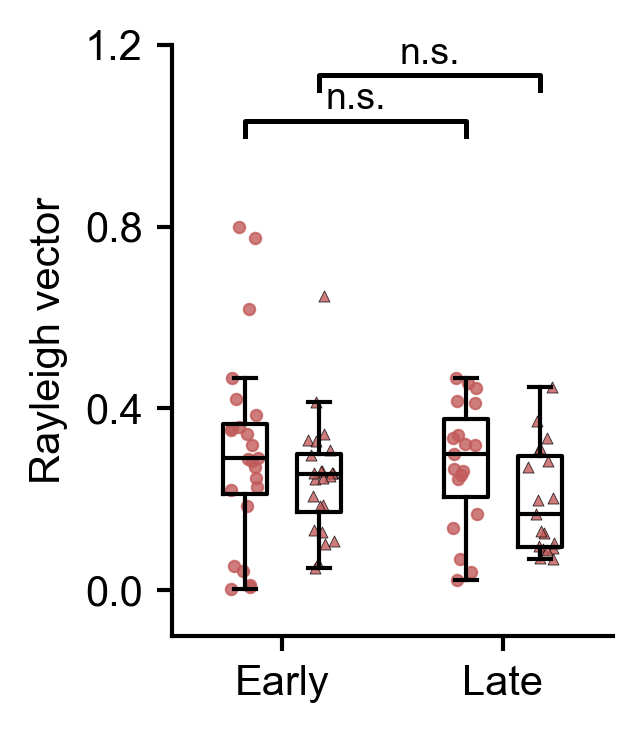

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Results4Plots/HeadDirectionCells.csv")

for col in ["Animal", "Stage", "Region", "Environment"]:
    df[col] = df[col].astype("string").str.strip().str.strip("'\"")

df["Trial"] = pd.to_numeric(df["Trial"], errors="coerce")
df["RayleighVector"] = pd.to_numeric(df["RayleighVector"], errors="coerce")

def plot_stage_env_panel(
    df_in,
    value_col,
    ylabel,
    save_path,
    vr_text="n.s.",
    r_text="n.s.",
    ylim=(-0.1, 1.2),
    yticks=None,
    vr_y=1.0,
    r_y=1.0
):
    dfp = df_in.copy()
    dfp[value_col] = pd.to_numeric(dfp[value_col], errors="coerce")

    dfp = dfp[
        (dfp["Stage"].isin(["early", "late"]))
        & (dfp["Environment"].isin(["R", "VR"]))
    ].dropna(subset=["Animal", "Trial", value_col]).copy()

    stage_levels = ["early", "late"]
    env_levels = ["VR", "R"]

    colorHD = np.array([194, 91, 91]) / 255.0

    xpos = {
        ("early", "VR"): 1,
        ("early", "R"): 2,
        ("late", "VR"): 4,
        ("late", "R"): 5
    }

    rng = np.random.default_rng(0)
    jitter_width = 0.4

    fig, ax = plt.subplots(figsize=(2, 2.3), dpi=300)

    for st in stage_levels:
        for env in env_levels:
            sub = dfp[(dfp["Stage"] == st) & (dfp["Environment"] == env)]
            y = sub[value_col].to_numpy(dtype=float)
            y = y[np.isfinite(y)]

            if y.size == 0:
                continue

            x0 = xpos[(st, env)]
            jitter = (rng.random(y.size) - 0.5) * jitter_width

            if env == "VR":
                ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=colorHD, edgecolors=colorHD, linewidths=0.5, alpha=0.8, zorder=2)
            else:
                ax.scatter(x0 + jitter, y, s=7, marker="^", facecolors=colorHD, edgecolors="k", linewidths=0.2, alpha=0.8, zorder=2)

            bp = ax.boxplot(
                y,
                positions=[x0],
                widths=0.6,
                showfliers=False,
                patch_artist=False,
                boxprops=dict(color="k", linewidth=1),
                medianprops=dict(color="k", linewidth=1),
                whiskerprops=dict(color="k", linewidth=1),
                capprops=dict(color="k", linewidth=1)
            )

            for k in ["boxes", "medians", "whiskers", "caps"]:
                for artist in bp[k]:
                    artist.set_zorder(10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

    for label in ax.get_yticklabels():
        label.set_fontname("Arial")

    ax.set_ylabel(ylabel, fontsize=10, fontname="Arial")
    ax.set_xticks([1.5, 4.5])
    ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)
    ax.set_xlim(0, 6)
    ax.set_ylim(ylim)

    if yticks is not None:
        ax.set_yticks(yticks)

    yr = ylim[1] - ylim[0]
    h = 0.025 * yr
    text_offset = 0.008 * yr

    ax.plot([1, 1, 4, 4], [vr_y, vr_y + h, vr_y + h, vr_y], lw=1.2, c="k")
    ax.text(2.5, vr_y + h + text_offset, vr_text, ha="center", va="bottom", fontname="Arial", fontsize=9)

    ax.plot([2, 2, 5, 5], [r_y, r_y + h, r_y + h, r_y], lw=1.2, c="k")
    ax.text(3.5, r_y + h + text_offset, r_text, ha="center", va="bottom", fontname="Arial", fontsize=9)

    fig.tight_layout(pad=0.2)
    plt.show()
    plt.close(fig)

df_ALL = df[df["Region"] == "ALL"].copy()

plot_stage_env_panel(
    df_ALL,
    value_col="RayleighVector",
    ylabel="Rayleigh vector",
    save_path="../Figures_v2/HD_RV0.22_ALL1_MEC1.pdf",
    vr_text="n.s.",
    r_text="n.s.",
    ylim=(-0.1, 1.2),
    yticks=[0, 0.4, 0.8, 1.2],
    vr_y=1.0,
    r_y=1.1
)

## Extended Data Fig. 4d

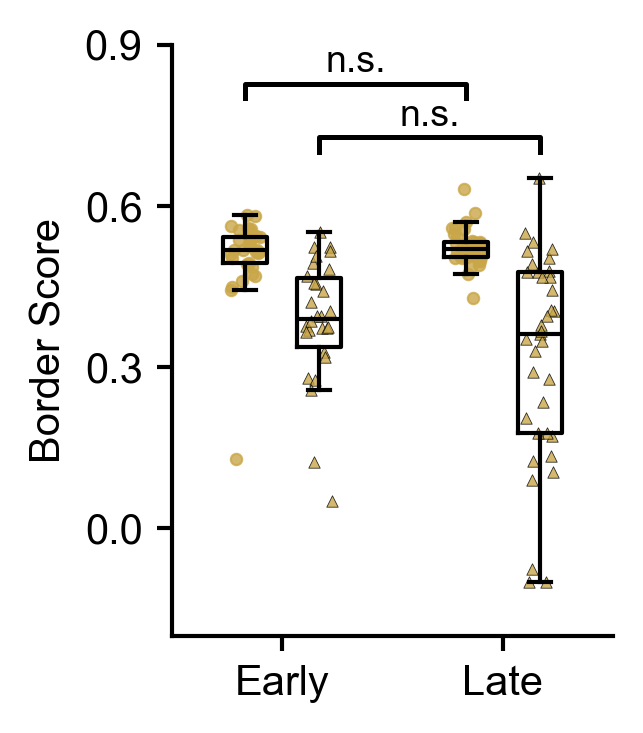

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Results4Plots/BorderCells.csv")

for col in ["Animal", "Stage", "Region", "Environment"]:
    df[col] = df[col].astype("string").str.strip().str.strip("'\"")

df["Trial"] = pd.to_numeric(df["Trial"], errors="coerce")
df["RayleighVector"] = pd.to_numeric(df["RayleighVector"], errors="coerce")

def plot_stage_env_panel(
    df_in,
    value_col,
    ylabel,
    save_path,
    vr_text="n.s.",
    r_text="n.s.",
    ylim=(-0.2, 0.9),
    yticks=None,
    vr_y=0.8,
    r_y=0.7
):
    dfp = df_in.copy()
    dfp[value_col] = pd.to_numeric(dfp[value_col], errors="coerce")

    dfp = dfp[
        (dfp["Stage"].isin(["early", "late"]))
        & (dfp["Environment"].isin(["R", "VR"]))
    ].dropna(subset=["Animal", "Trial", value_col]).copy()

    stage_levels = ["early", "late"]
    env_levels = ["VR", "R"]

    colorBC = np.array([201, 166, 72]) / 255.0

    xpos = {
        ("early", "VR"): 1,
        ("early", "R"): 2,
        ("late", "VR"): 4,
        ("late", "R"): 5
    }

    rng = np.random.default_rng(0)
    jitter_width = 0.4

    fig, ax = plt.subplots(figsize=(2, 2.3), dpi=300)

    for st in stage_levels:
        for env in env_levels:
            sub = dfp[(dfp["Stage"] == st) & (dfp["Environment"] == env)]
            y = sub[value_col].to_numpy(dtype=float)
            y = y[np.isfinite(y)]

            if y.size == 0:
                continue

            x0 = xpos[(st, env)]
            jitter = (rng.random(y.size) - 0.5) * jitter_width

            if env == "VR":
                ax.scatter(
                    x0 + jitter,
                    y,
                    s=7.5,
                    marker="o",
                    facecolors=colorBC,
                    edgecolors=colorBC,
                    linewidths=0.5,
                    alpha=0.8,
                    zorder=2
                )
            else:
                ax.scatter(
                    x0 + jitter,
                    y,
                    s=7.5,
                    marker="^",
                    facecolors=colorBC,
                    edgecolors="k",
                    linewidths=0.2,
                    alpha=0.8,
                    zorder=2
                )

            bp = ax.boxplot(
                y,
                positions=[x0],
                widths=0.6,
                showfliers=False,
                patch_artist=False,
                boxprops=dict(color="k", linewidth=1),
                medianprops=dict(color="k", linewidth=1),
                whiskerprops=dict(color="k", linewidth=1),
                capprops=dict(color="k", linewidth=1)
            )

            for k in ["boxes", "medians", "whiskers", "caps"]:
                for artist in bp[k]:
                    artist.set_zorder(10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

    for label in ax.get_yticklabels():
        label.set_fontname("Arial")

    ax.set_ylabel(ylabel, fontsize=10, fontname="Arial")
    ax.set_xticks([1.5, 4.5])
    ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)
    ax.set_xlim(0, 6)
    ax.set_ylim(ylim)

    if yticks is not None:
        ax.set_yticks(yticks)

    yr = ylim[1] - ylim[0]
    h = 0.025 * yr
    text_offset = 0.008 * yr

    ax.plot([1, 1, 4, 4], [vr_y, vr_y + h, vr_y + h, vr_y], lw=1.2, c="k")
    ax.text(2.5, vr_y + h + text_offset, vr_text, ha="center", va="bottom", fontname="Arial", fontsize=9)

    ax.plot([2, 2, 5, 5], [r_y, r_y + h, r_y + h, r_y], lw=1.2, c="k")
    ax.text(3.5, r_y + h + text_offset, r_text, ha="center", va="bottom", fontname="Arial", fontsize=9)

    fig.tight_layout(pad=0.2)
    plt.show()
    plt.close(fig)

df_ALL = df[df["Region"] == "ALL"].copy()

plot_stage_env_panel(
    df_ALL,
    value_col="RayleighVector",
    ylabel="Border Score",
    save_path="../Figures_v2/BC_ALL1_MEC_either2S3.pdf",
    vr_text="n.s.",
    r_text="n.s.",
    ylim=(-0.2, 0.9),
    yticks=[0, 0.3, 0.6, 0.9],
    vr_y=0.8,
    r_y=0.7
)

## Extended Data Fig. 4e & 4f

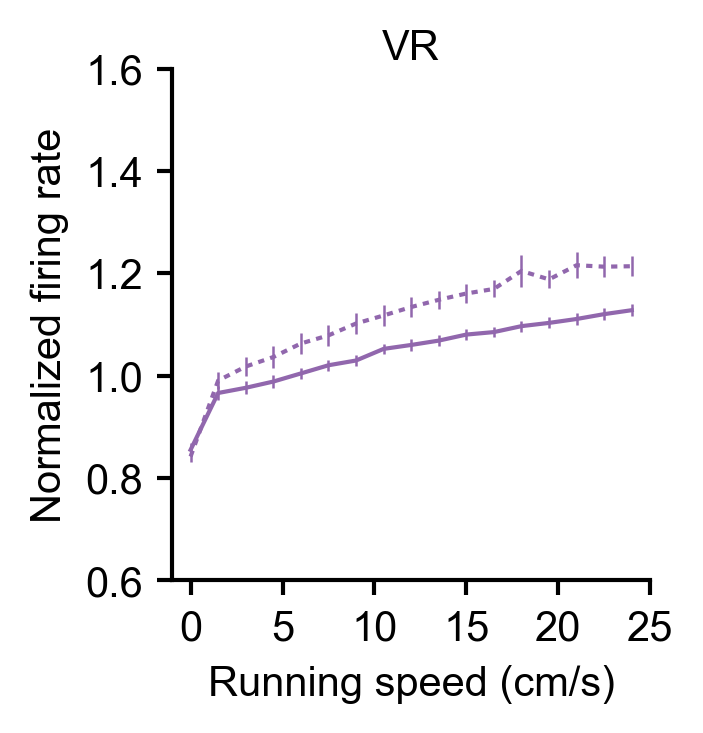

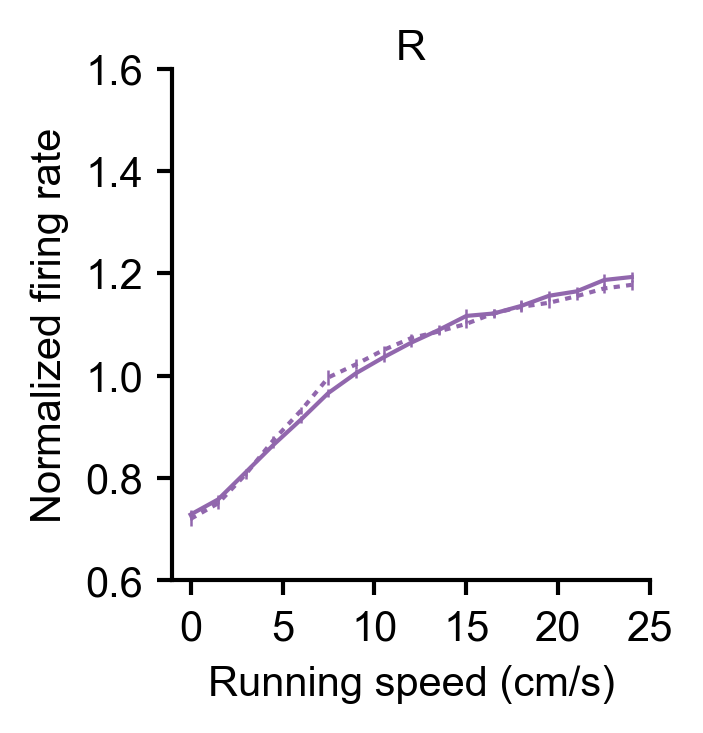

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

purple = np.array([145, 103, 173]) / 255.0

def make_plot_summary(data):
    data = data.copy()
    data["Speed"] = pd.to_numeric(data["Speed"], errors="coerce")
    data["Value"] = pd.to_numeric(data["Value"], errors="coerce")
    data = data.dropna(subset=["Stage", "Environment", "Speed", "Value"])

    summary = (
        data
        .groupby(["Stage", "Environment", "Speed"], observed=True)
        .agg(
            Mean=("Value", "mean"),
            SD=("Value", "std"),
            N_trials=("Value", "count")
        )
        .reset_index()
    )

    summary["SEM"] = summary["SD"] / np.sqrt(summary["N_trials"])

    return summary

def plot_FRvsRS_env(data, environment, title, save_path=None):
    summary = make_plot_summary(data)
    summary = summary[summary["Environment"] == environment].copy()

    fig, ax = plt.subplots(figsize=(2.2, 2.3), dpi=300)

    for stage in ["early", "late"]:
        sub = summary[summary["Stage"] == stage].sort_values("Speed")
        line_style = "--" if stage == "early" else "-"

        eb = ax.errorbar(
            sub["Speed"],
            sub["Mean"],
            yerr=sub["SEM"],
            color=purple,
            linestyle=line_style,
            linewidth=1,
            elinewidth=0.6,
            capsize=0,
            marker=None,
            zorder=3
        )

        if stage == "early":
            eb[0].set_dashes([1.5, 1.5])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname("Arial")

    ax.set_xlabel("Running speed (cm/s)", fontsize=10, fontname="Arial")
    ax.set_ylabel("Normalized firing rate", fontsize=10, fontname="Arial")
    ax.set_title(title, fontsize=10, fontname="Arial", y=0.97)

    ax.set_xlim(-1, 25)
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.set_ylim(0.6, 1.6)
    ax.set_yticks([0.6, 0.8, 1.0, 1.2, 1.4, 1.6])

    legend_handles = [
        Line2D([0], [0], color=purple, linestyle="--", linewidth=1, dashes=[1.5, 1.5], label="Early"),
        Line2D([0], [0], color=purple, linestyle="-", linewidth=1, label="Late")
    ]

    fig.tight_layout(pad=0.2)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

plot_FRvsRS_env(
    trial_all,
    environment="VR",
    title="VR",
)

plot_FRvsRS_env(
    trial_all,
    environment="R",
    title="R",
)

## Extended Data Fig. 4g

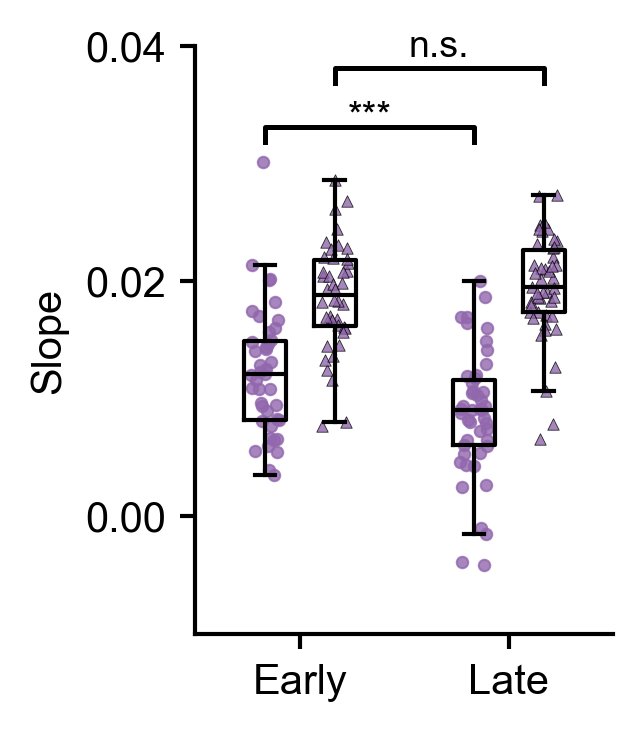

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Results4Plots/slopes.csv")

for col in ["Animal", "Stage"]:
    df[col] = df[col].astype("string").str.strip().str.strip("'\"")

for col in ["Trial", "R_slope", "VR_slope"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_long = df.melt(
    id_vars=["Animal", "Trial", "Stage"],
    value_vars=["R_slope", "VR_slope"],
    var_name="Environment",
    value_name="Value"
)

df_long["Environment"] = df_long["Environment"].replace({"R_slope": "R", "VR_slope": "VR"})

df_long = df_long[
    (df_long["Stage"].isin(["early", "late"]))
    & (df_long["Environment"].isin(["R", "VR"]))
].dropna(subset=["Animal", "Trial", "Value"]).copy()

def plot_speed_slope(
    df_in,
    vr_text="***",
    r_text="n.s.",
    ylim=(-0.01, 0.04),
    yticks=None
):
    colorSlope = np.array([145, 103, 173]) / 255.0

    xpos = {
        ("early", "VR"): 1,
        ("early", "R"): 2,
        ("late", "VR"): 4,
        ("late", "R"): 5
    }

    rng = np.random.default_rng(0)
    jitter_width = 0.4

    fig, ax = plt.subplots(figsize=(2, 2.3), dpi=300)

    for st in ["early", "late"]:
        for env in ["VR", "R"]:
            sub = df_in[(df_in["Stage"] == st) & (df_in["Environment"] == env)]
            y = sub["Value"].to_numpy(dtype=float)
            y = y[np.isfinite(y)]

            if y.size == 0:
                continue

            x0 = xpos[(st, env)]
            jitter = (rng.random(y.size) - 0.5) * jitter_width

            if env == "VR":
                ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=colorSlope, edgecolors=colorSlope, linewidths=0.5, alpha=0.8, zorder=2)
            else:
                ax.scatter(x0 + jitter, y, s=7.5, marker="^", facecolors=colorSlope, edgecolors="k", linewidths=0.2, alpha=0.8, zorder=2)

            bp = ax.boxplot(
                y,
                positions=[x0],
                widths=0.6,
                showfliers=False,
                patch_artist=False,
                boxprops=dict(color="k", linewidth=1),
                medianprops=dict(color="k", linewidth=1),
                whiskerprops=dict(color="k", linewidth=1),
                capprops=dict(color="k", linewidth=1)
            )

            for k in ["boxes", "medians", "whiskers", "caps"]:
                for artist in bp[k]:
                    artist.set_zorder(10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

    for label in ax.get_yticklabels():
        label.set_fontname("Arial")

    ax.set_ylabel("Slope", fontsize=10, fontname="Arial")
    ax.set_xticks([1.5, 4.5])
    ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)
    ax.set_xlim(0, 6)
    ax.set_ylim(ylim)

    if yticks is not None:
        ax.set_yticks(yticks)

    yr = ylim[1] - ylim[0]
    h = 0.025 * yr
    gap = 0.035 * yr
    text_offset = 0.008 * yr

    vr_values = df_in.loc[df_in["Environment"] == "VR", "Value"].to_numpy(dtype=float)
    r_values = df_in.loc[df_in["Environment"] == "R", "Value"].to_numpy(dtype=float)

    vr_values = vr_values[np.isfinite(vr_values)]
    r_values = r_values[np.isfinite(r_values)]

    y_vr = np.nanmax(vr_values) + gap
    y_r = max(np.nanmax(r_values) + gap, y_vr + 0.10 * yr)

    ax.plot([1, 1, 4, 4], [y_vr, y_vr + h, y_vr + h, y_vr], lw=1.2, c="k", clip_on=False)
    ax.text(2.5, y_vr + h + text_offset - 0.001, vr_text, ha="center", va="bottom", fontname="Arial", fontsize=9, clip_on=False)

    ax.plot([2, 2, 5, 5], [y_r, y_r + h, y_r + h, y_r], lw=1.2, c="k", clip_on=False)
    ax.text(3.5, y_r + h + text_offset, r_text, ha="center", va="bottom", fontname="Arial", fontsize=9, clip_on=False)

    fig.tight_layout(pad=0.2)
    plt.show()
    plt.close(fig)

plot_speed_slope(
    df_long,
    vr_text="***",
    r_text="n.s.",
    ylim=(-0.01, 0.04),
    yticks=[0, 0.02, 0.04]
)